In [7]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns


# What is the causal effect of a client's decision to open a deposit?

- `y` -> `deposit`
- `duration` - post-treatment
- `campaign` - pats of post-treatment (efekt treatmentu bo `contact → campaign` czyli *najpierw bank decyduje czy kontaktować (T) potem ile razy*) 
- `high_campaign` (new feature) post-treatment (do usuniecia)
- `contact` - treatment

Treatment (T) → czy klient był intensywnie targetowany

Outcome (Y) → deposit

Confounders (X) → demografia + finanse + historia

👉 ustalić co jest treatmentem w zbiorze? 

Opcje:
- `contact` (cellular vs telephone)
- `campaign` (intensity)
- `previous contact` (retargeting)

👉 ustalic co jest `confunder` w zbiorze (co wpływa na T i Y)

Opcje:
- `balance` - prawd. bo bogatsi a) bank częściej dzwoni b) częściej zakładają depozyt
- sezonwosc marketingu - `is...campaign`
- `financial_stress` 

    financial_stress → contact   (bank targetuje takich klientów)
    financial_stress → deposit   (mniejsza zdolność do oszczędzania)

👉 ustalic co jest `colliderem / post-treatment`:
- `duration` bo:

bank dzwoni (contact)
rozmowa trwa (duration)
klient decyduje (deposit)

👉 usalic co jest `Propensity score` - prawd. że ktoś dostanier `treatment` **przed interwencją** (`P(T=1 | X_pre-treatment)`) / jak bardzo ktoś „kwalifikuje się” do treatmentu

!**tylko z PRE-TREATMENT variables**!

- `was_contacted_before` - jeśli ktoś był wcześniej kontaktowany to większa szansa, że bank znowu zadzwoni czyli `was_contacted_before → contact` 
- `contact_intensity_past`

Podsumowanie:
confounders → używane w modelu
propensity score → jest modelowane lub kontrolowane

In [8]:
df = pd.read_csv('../data/raw/bank.csv')


In [9]:
# Zamiana 'yes' na 1 i 'no' na 0
df['deposit'] = df['deposit'].map({'yes': 1, 'no': 0})

In [10]:
display(df)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,1
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,1
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,1
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,1
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11157,33,blue-collar,single,primary,no,1,yes,no,cellular,20,apr,257,1,-1,0,unknown,0
11158,39,services,married,secondary,no,733,no,no,unknown,16,jun,83,4,-1,0,unknown,0
11159,32,technician,single,secondary,no,29,no,no,cellular,19,aug,156,2,-1,0,unknown,0
11160,43,technician,married,secondary,no,0,no,yes,cellular,8,may,9,2,172,5,failure,0


## 1. Podstawowy Feature Engineering 

na podstawie EDA i analizy istotności cech

- Rozdzielenie `pdays` na dwie cechy: informacja o wcześniejszym kontakcie oraz liczba dni od kontaktu
- Log-transformacja dla silnie skośnych zmiennych (`previous`, `balance`)
- Ograniczenie wartości maksymalnych w `campaign`
- Przygotowanie zmiennych kategorycznych z dużym udziałem "unknown"
- Usunięcie/ignorowanie zmiennej `duration` (post-treatment)


In [ ]:
# Noew cechy - inżynieria cech
df['has_debt'] = ((df['housing'] == 'yes') | (df['loan'] == 'yes')).astype(int) # długi wpływają na decyzje depozytu


# dodanie nowej zminnej - wskaźnik czy klient ma dodatnie saldo
df['net_balance_indicator'] = (df['balance'] > 0).astype(int)

# ryzyko finansowe - confunder
df['financial_stress'] = (
    (df['balance'] < 0) |
    (df['loan'] == 'yes') |
    (df['default'] == 'yes')
).astype(int)

### a) Rozdzielenie `pdays` na dwie cechy

In [11]:
# (a) Czy był wcześniejszy kontakt
# (b) Liczba dni od kontaktu (dla pdays > -1)
df['was_previously_contacted'] = (df['pdays'] != -1).astype(int)
df['pdays_contacted'] = df['pdays'].where(df['pdays'] != -1, np.nan)


### b) Log-transformacja dla silnie skośnych zmiennych

In [13]:
# previous: log1p (log(1+x)), balance: log1p(balance - min(balance) + 1)
df['previous_log1p'] = np.log1p(df['previous'])
min_balance = df['balance'].min()
df['balance_log1p'] = np.log1p(df['balance'] - min_balance + 1)


In [14]:
num_cols = [col for col in ['previous', 'previous_log1p', 'balance', 'balance_log1p'] if col in df.columns]
if len(num_cols) > 0:
    print('Korelacje Pearsona dla cech numerycznych z targetem:')
    corr = df[num_cols + ['deposit']].corr(method='pearson')
    display(corr['deposit'].drop('deposit'))
else:
    print('Brak oryginalnych cech numerycznych do analizy korelacji.')

# Wynik poprawił się

Korelacje Pearsona dla cech numerycznych z targetem:


previous          0.139867
previous_log1p    0.209330
balance           0.081129
balance_log1p     0.111009
Name: deposit, dtype: float64

In [15]:
df = df.drop(columns=['previous', 'balance'])

### c) Ograniczenie wartości maksymalnych w campaign


In [16]:
# winsoryzacja na 99 percentylu -
# Oblcizenie wartości, poniżej której znajduje się 99% danych - w zbiorze to ~ 13 (bo max po wynosi 13)
campaign_cap = df['campaign'].quantile(0.99)
df['campaign_capped'] = np.where(df['campaign'] > campaign_cap, campaign_cap, df['campaign'])


In [17]:
# 3.2. Porównanie statystyk
print("=== PRZED ===")
print(df['campaign'].describe())

print("\n=== PO ===")
print(df['campaign_capped'].describe())

print("\nLiczba przyciętych wartości:", (df['campaign'] > campaign_cap).sum())

# Summary:
# - ucięto "ogon” rozkładu
# - zmniejszono wpływ ekstremów
# - Nadal większość danych została nietknięta

# teraz modele nie będą "przesadnie” karane za te ekstremalne wartości, które mogą być szumem lub outlierami, a nie prawdziwymi sygnałami.
# teraz modele wrażliwe na outliery (np. regresja liniowa) będą miały bardziej stabilne i wiarygodne wyniki, a modele mniej wrażliwe (np. drzewa) nadal będą mogły wykorzystać te dane bez ryzyka nadmiernego dopasowania do ekstremów.

=== PRZED ===
count    11162.000000
mean         2.508421
std          2.722077
min          1.000000
25%          1.000000
50%          2.000000
75%          3.000000
max         63.000000
Name: campaign, dtype: float64

=== PO ===
count    11162.000000
mean         2.433883
std          2.176754
min          1.000000
25%          1.000000
50%          2.000000
75%          3.000000
max         13.000000
Name: campaign_capped, dtype: float64

Liczba przyciętych wartości: 111


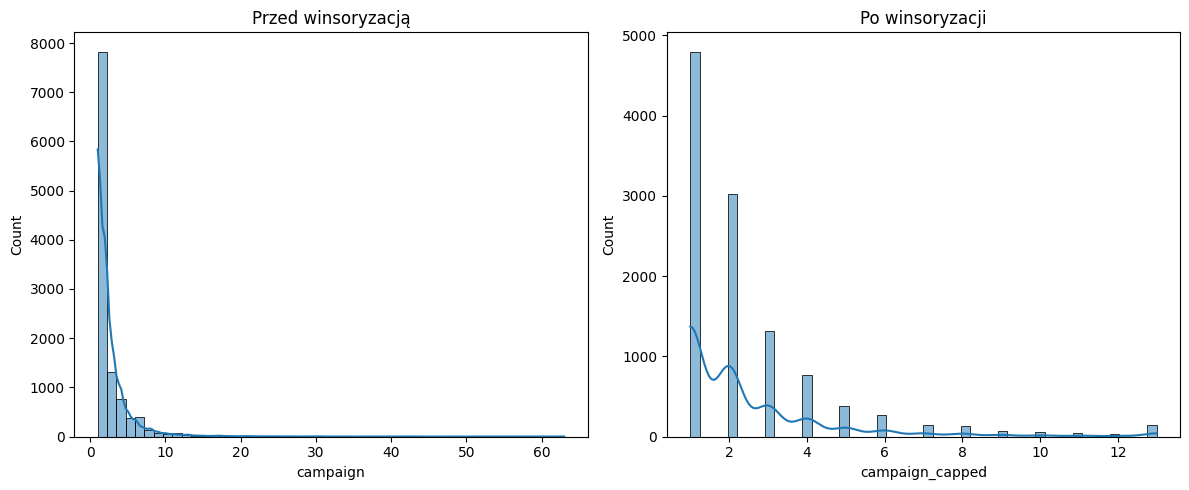

In [18]:
# 3.3. Wizualizacja rozkładów
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.histplot(df['campaign'], bins=50, kde=True)
plt.title('Przed winsoryzacją')

plt.subplot(1,2,2)
sns.histplot(df['campaign_capped'], bins=50, kde=True)
plt.title('Po winsoryzacji')

plt.tight_layout()
plt.show()

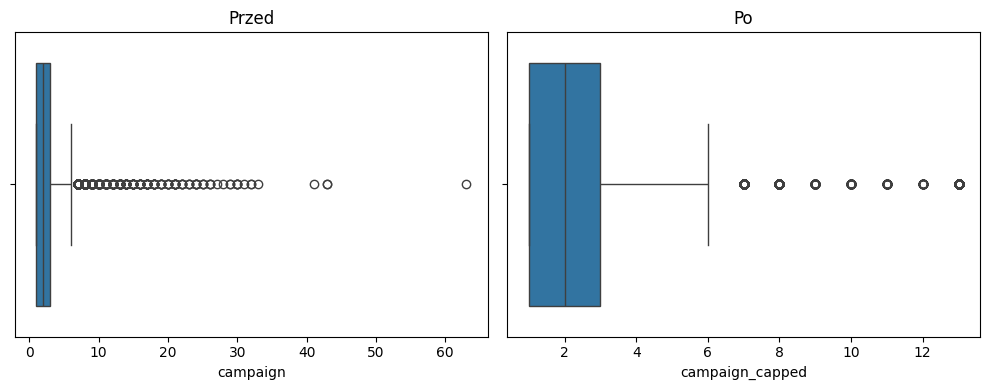

In [19]:
# 3.4. Boxplot dla lepszego zobaczenia outlierów
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.boxplot(x=df['campaign'])
plt.title('Przed')

plt.subplot(1,2,2)
sns.boxplot(x=df['campaign_capped'])
plt.title('Po')

plt.tight_layout()
plt.show()

In [20]:

num_cols = [col for col in ['campaign', 'campaign_capped'] if col in df.columns]
if len(num_cols) > 0:
    print('Korelacje Pearsona dla cech numerycznych z targetem:')
    corr = df[num_cols + ['deposit']].corr(method='pearson')
    display(corr['deposit'].drop('deposit'))
else:
    print('Brak oryginalnych cech numerycznych do analizy korelacji.')

Korelacje Pearsona dla cech numerycznych z targetem:


campaign          -0.128081
campaign_capped   -0.136161
Name: deposit, dtype: float64

In [21]:
df = df.drop(columns=['campaign']) # usuwanie starej

### d) Przygotowanie zmiennych kategorycznych z dużym udziałem "unknown"

In [22]:
# dodatkowy sygnał dla przyszlych modeli - czy wgl cos wiemy o tej cesze
for col in ['poutcome', 'education', 'contact']:
    if col in df.columns:
        df[col + '_is_unknown'] = (df[col] == 'unknown').astype(int)


In [23]:
num_cols = [col for col in ['poutcome', 'poutcome_is_unknown', 'education', 'education_is_unknown', 'contact', 'contact_is_unknown'] if col in df.columns]

# uwagi: 
# 1. brak może być:
# - losowy (MCAR) → wtedy raczej nie wnosi dużo
# - systematyczny (MNAR) → wtedy może być bardzo informatywny

# taka flaga może działać jak proxy dla ukrytych procesów biznesowych

# Interpretacja predykcyjna - brak informacji jest zlym sygnałem
# Interpretacja przyczynowa - flaga moze być
#   a) konfunderem
#      jakość systemu CRM → wpływa na:
#       - brak danych (unknown)
#       - sukces kampanii (deposit)
#   b) colliderem
#      dwie rzeczy mogą wpływać na unknown
#   c) proxy zmiennej ukrytej
#      np kompetencje pracownika OR segment klienta
# ^^^ Trzeba wiedziec dalczego jest unknown aby używać w causal interference

In [24]:
df[num_cols].describe()

,poutcome_is_unknown,education_is_unknown,contact_is_unknown
count,11162.000000,11162.000000,11162.000000
mean,0.745924,0.044526,0.210177
std,0.435360,0.206270,0.407453
min,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000
50%,1.000000,0.000000,0.000000
75%,1.000000,0.000000,0.000000
max,1.000000,1.000000,1.000000


In [25]:
df.groupby('poutcome_is_unknown')['deposit'].mean()

poutcome_is_unknown
0    0.671016
1    0.406678
Name: deposit, dtype: float64

In [26]:
# nisak korelacja - NIEISTOTNE
df.groupby('education_is_unknown')['deposit'].mean()

education_is_unknown
0    0.472293
1    0.507042
Name: deposit, dtype: float64

In [27]:
df.groupby('contact_is_unknown')['deposit'].mean()

contact_is_unknown
0    0.539814
1    0.225916
Name: deposit, dtype: float64

In [28]:
num_cols = [col for col in ['poutcome_is_unknown', 'education_is_unknown', 'contact_is_unknown'] if col in df.columns]
if len(num_cols) > 0:
    print('Korelacje Pearsona dla cech numerycznych z targetem:')
    corr = df[num_cols + ['deposit']].corr(method='pearson')
    display(corr['deposit'].drop('deposit'))
else:
    print('Brak oryginalnych cech numerycznych do analizy korelacji.')

Korelacje Pearsona dla cech numerycznych z targetem:


poutcome_is_unknown    -0.230470
education_is_unknown    0.014355
contact_is_unknown     -0.256136
Name: deposit, dtype: float64

In [29]:
df = df.drop(columns=['education_is_unknown'])

In [30]:
import pandas as pd
import numpy as np

# --- 1. podział na grupy ---
df_unknown = df[df['contact_is_unknown'] == 1]
df_known = df[df['contact_is_unknown'] == 0]

print("Liczba obserwacji:")
print("unknown:", len(df_unknown))
print("known:", len(df_known))

print("\n--- DEPENDENT VARIABLE ---") # Wniosek: klienci z contact_is_unknown=1 są dużo mniej skłonni do depozytu
print("Deposit rate (unknown):", df_unknown['deposit'].mean())
print("Deposit rate (known):", df_known['deposit'].mean())


# --- 2. PDAYS (kluczowa zmienna historyczna) ---
print("\n--- PDAYS ANALYSIS ---")

print("pdays == -1 (brak kontaktu wcześniej):") 
print("unknown:", (df_unknown['pdays'] == -1).mean()) # 99% klientów z unknown NIE było wcześniej kontaktowany „cold start clients”
print("known:", (df_known['pdays'] == -1).mean())

print("\nŚredni pdays (tylko gdy != -1):")
print("unknown:",
      df_unknown.loc[df_unknown['pdays'] != -1, 'pdays'].mean())
print("known:",
      df_known.loc[df_known['pdays'] != -1, 'pdays'].mean())


# --- 3. PREVIOUS (historia kontaktów) ---
print("\n--- PREVIOUS CONTACTS ---")
print("Średnia previous:")
print("unknown:", df_unknown['previous_log1p'].mean()) # niewiele relacji z bankiem marketingowym (malo kontaktu)
print("known:", df_known['previous_log1p'].mean())


# --- 4. CAMPAIGN (intensywność kontaktów w bieżącej kampanii) ---
print("\n--- CAMPAIGN ---")
print("Średnia liczba kontaktów:")
print("unknown:", df_unknown['campaign_capped'].mean())
print("known:", df_known['campaign_capped'].mean())


# --- 5. BALANCE (czy to inny segment klientów?) ---
print("\n--- BALANCE ---")
print("Średnie saldo:")
print("unknown:", df_unknown['balance_log1p'].mean())
print("known:", df_known['balance_log1p'].mean())


# --- 6. AGE (profil demograficzny) ---
print("\n--- AGE ---")
print("Średni wiek:")
print("unknown:", df_unknown['age'].mean())
print("known:", df_known['age'].mean())

Liczba obserwacji:
unknown: 2346
known: 8816

--- DEPENDENT VARIABLE ---
Deposit rate (unknown): 0.2259164535379369
Deposit rate (known): 0.5398139745916516

--- PDAYS ANALYSIS ---
pdays == -1 (brak kontaktu wcześniej):
unknown: 0.9919011082693947
known: 0.6802404718693285

Średni pdays (tylko gdy != -1):
unknown: 448.7368421052632
known: 203.1741752394466

--- PREVIOUS CONTACTS ---
Średnia previous:
unknown: 0.010627078886106449
known: 0.40610294862851903

--- CAMPAIGN ---
Średnia liczba kontaktów:
unknown: 2.607843137254902
known: 2.3875907441016335

--- BALANCE ---
Średnie saldo:
unknown: 8.968589805352241
known: 9.00281445997409

--- AGE ---
Średni wiek:
unknown: 40.35763000852515
known: 41.46460980036298


**Wnioski**:

1. `poutcome_is_unknown`


0 → 0.671
1 → 0.407

👉 spadek ~ -0.26

Interpretacja:

Jeśli brak informacji o poprzednim wyniku kampanii, to - konwersja jest dużo niższa

Co to może oznaczać:

Jeśli `previous` (liczba kontaktów w poprzedniej kampani jest unknown/nan/ 0) i `poutcome_is_unknown = 1` to mamy pewność że kontaktu nie było!!!

2. `contact_is_unknown`

0 → 0.540
1 → 0.226

👉 spadek ~ -0.31 (bardzo duży efekt)

Interpretacja:

Brak informacji o formie kontaktu

To jest jedna z najsilniejszych obserwacji tutaj.

Możliwe wyjaśnienia:
- na podstawie `deposit rate` & `pdays` - widać że to segment klientów bez historii kontaktu w kampaniach 
- klienci z contact_is_unknown=1 są dużo mniej skłonni do depozytu


3. education_is_unknown - **nie wnosi stabilnej informacji predykcyjnej.**
Kandydat do suunięcia

In [31]:
# 5. Usunięcie zmiennej duration (nie używamy jej do modelowania przyczynowego)
# if 'duration' in df.columns:
#     df = df.drop(columns=['duration'])


-------

In [32]:
# Podsumowanie nowych cech
df.head()

,age,job,marital,education,default,housing,loan,contact,day,month,...,was_previously_contacted,pdays_contacted,has_debt,net_balance_indicator,financial_stress,previous_log1p,balance_log1p,campaign_capped,poutcome_is_unknown,contact_is_unknown
0,59,admin.,married,secondary,no,yes,no,unknown,5,may,...,0,NaN,1,1,0,0.0,9.126089,1.0,1,1
1,56,admin.,married,secondary,no,no,no,unknown,5,may,...,0,NaN,0,1,0,0.0,8.838407,1.0,1,1
2,41,technician,married,secondary,no,yes,no,unknown,5,may,...,0,NaN,1,1,0,0.0,9.001962,1.0,1,1
3,55,services,married,secondary,no,yes,no,unknown,5,may,...,0,NaN,1,1,0,0.0,9.140454,1.0,1,1
4,54,admin.,married,tertiary,no,no,no,unknown,5,may,...,0,NaN,0,1,0,0.0,8.858369,2.0,1,1


In [33]:
num_cols = [col for col in ['age', 'previous_log1p', 'balance_log1p', 'campaign_capped', 'was_previously_contacted', 'pdays_contacted', 'previous', 'day', 'duration', 'poutcome_is_unknown', 'contact_is_unknown'] if col in df.columns]
if len(num_cols) > 0:
    print('Korelacje Pearsona dla cech numerycznych z targetem:')
    corr = df[num_cols + ['deposit']].corr(method='pearson')
    display(corr['deposit'].drop('deposit'))
else:
    print('Brak oryginalnych cech numerycznych do analizy korelacji.')

# was_previously_contacted: 0.23                
# previous:                 0.13 -> 0.20        liczba kontaktów w poprzedniej kampanii
# campaign_capped          -0.12 -> -0.13       Uwaga: im więcej kontaktów w bieżącej kampanii → tym mniejsza szansa sukcesu
# balance:                  0.08 -> 0.11
# pdays_contacted (pdays):  0.15 -> -0.14 xD    Uwaga: im więcej dni minęło od kontaktu → tym mniejsza szansa na depozyt
# duration:                 0.45 -> 0.45 (nie zmieniona) ALE nie powinna być używana w modelach przyczynowych (post-treatment).

Korelacje Pearsona dla cech numerycznych z targetem:


age                         0.034901
previous_log1p              0.209330
balance_log1p               0.111009
campaign_capped            -0.136161
was_previously_contacted    0.230850
pdays_contacted            -0.143814
day                        -0.056326
duration                    0.451919
poutcome_is_unknown        -0.230470
contact_is_unknown         -0.256136
Name: deposit, dtype: float64

-------------

In [34]:
# One hot encoding na czystej kolumnie
cat_cols = ['poutcome', 'contact', 'education']

df = pd.get_dummies(df, columns=cat_cols, prefix=cat_cols)
df = df.drop(columns=['poutcome_unknown', 'contact_unknown']) # education zosatwiamy poniweaz nie dsotaał soobnej kolumny 'is_unknown'

df.columns


Index(['age', 'job', 'marital', 'default', 'housing', 'loan', 'day', 'month',
       'duration', 'pdays', 'deposit', 'was_previously_contacted',
       'pdays_contacted', 'has_debt', 'net_balance_indicator',
       'financial_stress', 'previous_log1p', 'balance_log1p',
       'campaign_capped', 'poutcome_is_unknown', 'contact_is_unknown',
       'poutcome_failure', 'poutcome_other', 'poutcome_success',
       'contact_cellular', 'contact_telephone', 'education_primary',
       'education_secondary', 'education_tertiary', 'education_unknown'],
      dtype='str')

## Zapis nowego zbioru

In [35]:
df.to_csv('../data/processed/bank_data_preprocessed_v1.csv', index=False)

In [36]:
df.head()

,age,job,marital,default,housing,loan,day,month,duration,pdays,...,contact_is_unknown,poutcome_failure,poutcome_other,poutcome_success,contact_cellular,contact_telephone,education_primary,education_secondary,education_tertiary,education_unknown
0,59,admin.,married,no,yes,no,5,may,1042,-1,...,1,False,False,False,False,False,False,True,False,False
1,56,admin.,married,no,no,no,5,may,1467,-1,...,1,False,False,False,False,False,False,True,False,False
2,41,technician,married,no,yes,no,5,may,1389,-1,...,1,False,False,False,False,False,False,True,False,False
3,55,services,married,no,yes,no,5,may,579,-1,...,1,False,False,False,False,False,False,True,False,False
4,54,admin.,married,no,no,no,5,may,673,-1,...,1,False,False,False,False,False,False,False,True,False
